# PetFinder Adoption Prediction — Exploratory Data Analysis

**Materia:** Laboratorio de Implementación II · Universidad Austral · Abril 2026

**Autores:** Roxana Alberti · Sandra Sschicchi · Fernando Paganini · Baltazar Villanueva · Paula Calviello · Rosana Martinez

---

**Objetivo:** Predecir la velocidad de adopción de mascotas (perros y gatos) a partir de variables tabulares, texto de descripción, análisis de sentimientos e imágenes (anotadas con Google Cloud Vision API).

**Variable target:** `AdoptionSpeed`
- 0 — Adoptado el mismo día del listado
- 1 — Adoptado entre 1 y 7 días
- 2 — Adoptado entre 8 y 30 días
- 3 — Adoptado entre 31 y 90 días
- 4 — No adoptado después de 100 días

**Dataset:** Malaysia (PetFinder.my) — 14,993 registros de entrenamiento

In [1]:
import pandas as pd
import numpy as np
import json
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# ── Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
    'legend.labelcolor':'#e0e0e0',
    'font.family':      'DejaVu Sans',
})

PALETTE_SPEED = ['#00d4aa', '#4ecdc4', '#ffe66d', '#ff6b6b', '#c0392b']
PALETTE_TYPE  = ['#4A90D9', '#E8A838']
PALETTE_MAIN  = sns.color_palette('mako', 8)

from pathlib import Path
_base = Path.cwd()
while not (_base / 'input').exists() and _base != _base.parent:
    _base = _base.parent
BASE = str(_base / 'input')
print(f'BASE detectado: {BASE}')
print('Setup complete ✓')

BASE detectado: C:\Users\User\Desktop\MCD\Laboratorio de Implementacion II\GitHub\UA_MDM_Labo2\input
Setup complete ✓


## 1. Carga de datos

In [2]:
# ── Tabular data ───────────────────────────────────────────────────────
train = pd.read_csv(f'{BASE}/train/train.csv')
test  = pd.read_csv(f'{BASE}/test/test.csv')

# ── Label maps ────────────────────────────────────────────────────────
breed_labels = pd.read_csv(f'{BASE}/breed_labels.csv')
color_labels = pd.read_csv(f'{BASE}/color_labels.csv')
state_labels = pd.read_csv(f'{BASE}/state_labels.csv')

# ── Decode categorical columns ────────────────────────────────────────
TYPE_MAP   = {1: 'Dog', 2: 'Cat'}
GENDER_MAP = {1: 'Male', 2: 'Female', 3: 'Mixed'}
SIZE_MAP   = {1: 'Small', 2: 'Medium', 3: 'Large', 4: 'Extra Large', 0: 'Not Specified'}
FUR_MAP    = {1: 'Short', 2: 'Medium', 3: 'Long', 0: 'Not Specified'}
YN_MAP     = {1: 'Yes', 2: 'No', 3: 'Not Sure'}
HEALTH_MAP = {1: 'Healthy', 2: 'Minor Issues', 3: 'Serious Issues'}
SPEED_MAP  = {0: '0 – Same day', 1: '1 – 1–7 days', 2: '2 – 8–30 days',
               3: '3 – 31–90 days', 4: '4 – Not adopted'}

color_map  = dict(zip(color_labels.ColorID, color_labels.ColorName))
state_map  = dict(zip(state_labels.StateID, state_labels.StateName))
breed_map  = dict(zip(breed_labels.BreedID, breed_labels.BreedName))

train['TypeName']       = train['Type'].map(TYPE_MAP)
train['GenderName']     = train['Gender'].map(GENDER_MAP)
train['SizeName']       = train['MaturitySize'].map(SIZE_MAP)
train['FurName']        = train['FurLength'].map(FUR_MAP)
train['VaccinatedName'] = train['Vaccinated'].map(YN_MAP)
train['DewormedName']   = train['Dewormed'].map(YN_MAP)
train['SterilizedName'] = train['Sterilized'].map(YN_MAP)
train['HealthName']     = train['Health'].map(HEALTH_MAP)
train['StateName']      = train['State'].map(state_map)
train['Color1Name']     = train['Color1'].map(color_map)
train['Breed1Name']     = train['Breed1'].map(breed_map)
train['SpeedLabel']     = train['AdoptionSpeed'].map(SPEED_MAP)
train['HasName']        = train['Name'].notna() & (train['Name'].str.strip() != '')
train['DescLen']        = train['Description'].fillna('').apply(len)

print(f'Train: {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Test:  {test.shape[0]:,} rows × {test.shape[1]} cols')
train.head(3)

Train: 14,993 rows × 38 cols
Test:  3,972 rows × 23 cols


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,VaccinatedName,DewormedName,SterilizedName,HealthName,StateName,Color1Name,Breed1Name,SpeedLabel,HasName,DescLen
0,2,Nibble,3,299,0,1,1,7,0,1,...,No,No,No,Healthy,Selangor,Black,Tabby,2 – 8–30 days,True,359
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,Not Sure,Not Sure,Not Sure,Healthy,Kuala Lumpur,Black,Domestic Medium Hair,0 – Same day,True,118
2,1,Brisco,1,307,0,1,2,7,0,2,...,Yes,Yes,No,Healthy,Selangor,Brown,Mixed Breed,3 – 31–90 days,True,393


## 2. Carga de sentimientos y metadatos de imágenes

In [3]:
def load_sentiment(base_dir):
    """Extrae score y magnitude del documento de cada archivo de sentimiento."""
    records = []
    for fp in glob.glob(f'{base_dir}/*.json'):
        pet_id = os.path.basename(fp).replace('.json', '')
        try:
            with open(fp, 'r') as f:
                d = json.load(f)
            doc = d.get('documentSentiment', {})
            records.append({
                'PetID':     pet_id,
                'sent_score': doc.get('score', np.nan),
                'sent_mag':   doc.get('magnitude', np.nan),
                'n_sentences': len(d.get('sentences', [])),
                'n_entities':  len(d.get('entities', [])),
            })
        except Exception:
            pass
    return pd.DataFrame(records)


def load_metadata(base_dir):
    """Extrae scores medios de Vision API labels e info de colores dominantes."""
    records = []
    for fp in glob.glob(f'{base_dir}/*.json'):
        fname  = os.path.basename(fp).replace('.json', '')
        parts  = fname.rsplit('-', 1)
        pet_id = parts[0]
        try:
            with open(fp, 'r') as f:
                d = json.load(f)
            labels = d.get('labelAnnotations', [])
            label_scores = [l['score'] for l in labels]
            top_score    = max(label_scores) if label_scores else np.nan
            mean_score   = np.mean(label_scores) if label_scores else np.nan
            n_labels     = len(labels)

            colors = d.get('imagePropertiesAnnotation', {}) \
                      .get('dominantColors', {}) \
                      .get('colors', [])
            dom_score = colors[0]['score'] if colors else np.nan

            records.append({
                'PetID':          pet_id,
                'vision_top_score':  top_score,
                'vision_mean_score': mean_score,
                'vision_n_labels':   n_labels,
                'vision_dom_color_score': dom_score,
            })
        except Exception:
            pass
    df = pd.DataFrame(records)
    # Aggregate per PetID (multiple images per pet)
    return df.groupby('PetID').agg(
        vision_top_score  =('vision_top_score',  'mean'),
        vision_mean_score =('vision_mean_score', 'mean'),
        vision_n_labels   =('vision_n_labels',   'mean'),
        n_images          =('vision_top_score',  'count'),
    ).reset_index()


print('Cargando sentimientos...', end=' ')
sent_train = load_sentiment(f'{BASE}/train_sentiment')
print(f'{len(sent_train):,} registros ✓')

print('Cargando metadatos Vision API...', end=' ')
meta_train = load_metadata(f'{BASE}/train_metadata')
print(f'{len(meta_train):,} pets con imágenes ✓')

# ── Merge into train ───────────────────────────────────────────────────
train = train.merge(sent_train, on='PetID', how='left')
train = train.merge(meta_train, on='PetID', how='left')

print(f'\nTrain enriquecido: {train.shape[0]:,} × {train.shape[1]} cols')

Cargando sentimientos... 

14,204 registros ✓
Cargando metadatos Vision API... 

14,642 pets con imágenes ✓

Train enriquecido: 14,993 × 46 cols


## 3. Overview general del dataset

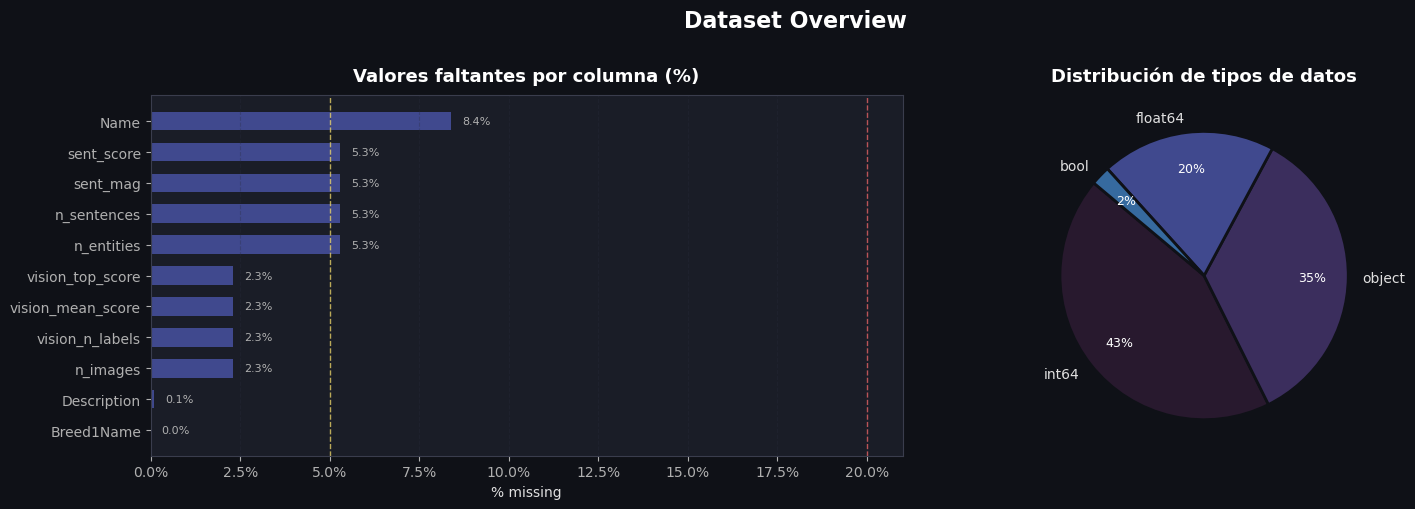


Resumen estadístico (numéricas):


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,AdoptionSpeed,DescLen,sent_score,sent_mag,n_sentences,n_entities,vision_top_score,vision_mean_score,vision_n_labels,n_images
count,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,...,14993.00,14993.00,14204.00,14204.00,14204.00,14204.00,14642.00,14642.00,14642.00,14642.00
mean,1.46,10.45,265.27,74.01,1.78,2.23,3.22,1.88,1.86,1.47,...,2.52,339.31,0.28,2.10,5.04,10.96,0.97,0.78,9.38,3.97
std,0.50,18.16,60.06,123.01,0.68,1.75,2.74,2.98,0.55,0.60,...,1.18,373.37,0.28,1.98,4.65,11.30,0.02,0.04,0.91,3.47
min,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,...,0.00,0.00,-0.90,0.00,1.00,0.00,0.52,0.52,0.50,1.00
25%,1.00,2.00,265.00,0.00,1.00,1.00,0.00,0.00,2.00,1.00,...,2.00,117.00,0.10,0.80,2.00,4.00,0.96,0.76,9.00,2.00
50%,1.00,3.00,266.00,0.00,2.00,2.00,2.00,0.00,2.00,1.00,...,2.00,238.00,0.30,1.60,4.00,8.00,0.97,0.78,9.80,3.00
75%,2.00,12.00,307.00,179.00,2.00,3.00,6.00,5.00,2.00,2.00,...,4.00,431.00,0.40,2.80,6.00,14.00,0.99,0.80,10.00,5.00
max,2.00,255.00,307.00,307.00,3.00,7.00,7.00,7.00,4.00,3.00,...,4.00,6664.00,0.90,32.00,84.00,207.00,1.00,0.93,10.00,30.00


In [4]:
# ── Missing values ─────────────────────────────────────────────────────
miss = train.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(train) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f1117')
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold', color='white', y=1.01)

# Missings
ax = axes[0]
bars = ax.barh(miss_pct.index[::-1], miss_pct.values[::-1],
               color=PALETTE_MAIN[2], edgecolor='none', height=0.6)
ax.set_title('Valores faltantes por columna (%)', pad=10)
ax.set_xlabel('% missing')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvline(x=5,  color='#ffe66d', lw=1, ls='--', alpha=0.7)
ax.axvline(x=20, color='#ff6b6b', lw=1, ls='--', alpha=0.7)
for bar, val in zip(bars, miss_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, color='#b0b0b0')
ax.set_facecolor('#1a1d27')
ax.grid(axis='x', alpha=0.3)

# Dtypes summary
ax2 = axes[1]
dtype_counts = train.dtypes.astype(str).value_counts()
wedge_colors = [PALETTE_MAIN[i] for i in range(len(dtype_counts))]
wedges, texts, autotexts = ax2.pie(
    dtype_counts.values, labels=dtype_counts.index,
    autopct='%1.0f%%', colors=wedge_colors,
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
for t in texts:      t.set_color('#e0e0e0')
for at in autotexts: at.set_color('white'); at.set_fontsize(9)
ax2.set_title('Distribución de tipos de datos', pad=10)
ax2.set_facecolor('#1a1d27')

plt.tight_layout()
plt.show()

print('\nResumen estadístico (numéricas):')
train.describe().round(2)

## 4. Variable objetivo — AdoptionSpeed

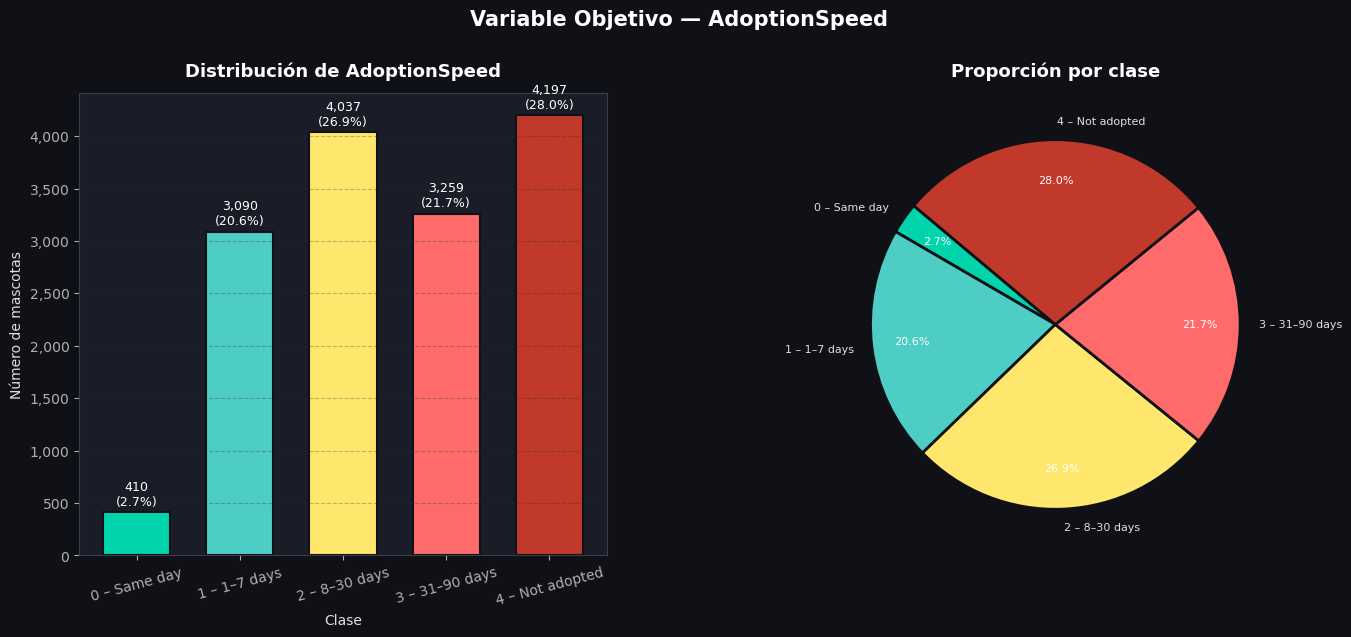

Distribución:
  0 – Same day: 410 (2.7%)
  1 – 1–7 days: 3,090 (20.6%)
  2 – 8–30 days: 4,037 (26.9%)
  3 – 31–90 days: 3,259 (21.7%)
  4 – Not adopted: 4,197 (28.0%)


In [5]:
fig = plt.figure(figsize=(16, 6), facecolor='#0f1117')
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

speed_counts = train['AdoptionSpeed'].value_counts().sort_index()
speed_labels = [SPEED_MAP[i] for i in speed_counts.index]

# Bar chart
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(speed_labels, speed_counts.values,
               color=PALETTE_SPEED, edgecolor='#0f1117', linewidth=1.5, width=0.65)
ax1.set_title('Distribución de AdoptionSpeed', pad=12)
ax1.set_xlabel('Clase')
ax1.set_ylabel('Número de mascotas')
ax1.tick_params(axis='x', rotation=15)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_facecolor('#1a1d27')
ax1.grid(axis='y', alpha=0.3)
total = speed_counts.sum()
for bar, val in zip(bars, speed_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
             f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom',
             fontsize=9, color='white')

# Pie
ax2 = fig.add_subplot(gs[1])
wedges, texts, auts = ax2.pie(
    speed_counts.values, labels=speed_labels,
    colors=PALETTE_SPEED, autopct='%1.1f%%',
    startangle=140, pctdistance=0.78,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
for t  in texts: t.set_color('#e0e0e0'); t.set_fontsize(8)
for at in auts:  at.set_color('white');  at.set_fontsize(8)
ax2.set_title('Proporción por clase', pad=12)
ax2.set_facecolor('#1a1d27')

fig.suptitle('Variable Objetivo — AdoptionSpeed', fontsize=15,
             fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

print('Distribución:')
for i, (cnt, lbl) in enumerate(zip(speed_counts.values, speed_labels)):
    print(f'  {lbl}: {cnt:,} ({cnt/total*100:.1f}%)')

## 5. Tipo de mascota (Perro vs Gato)

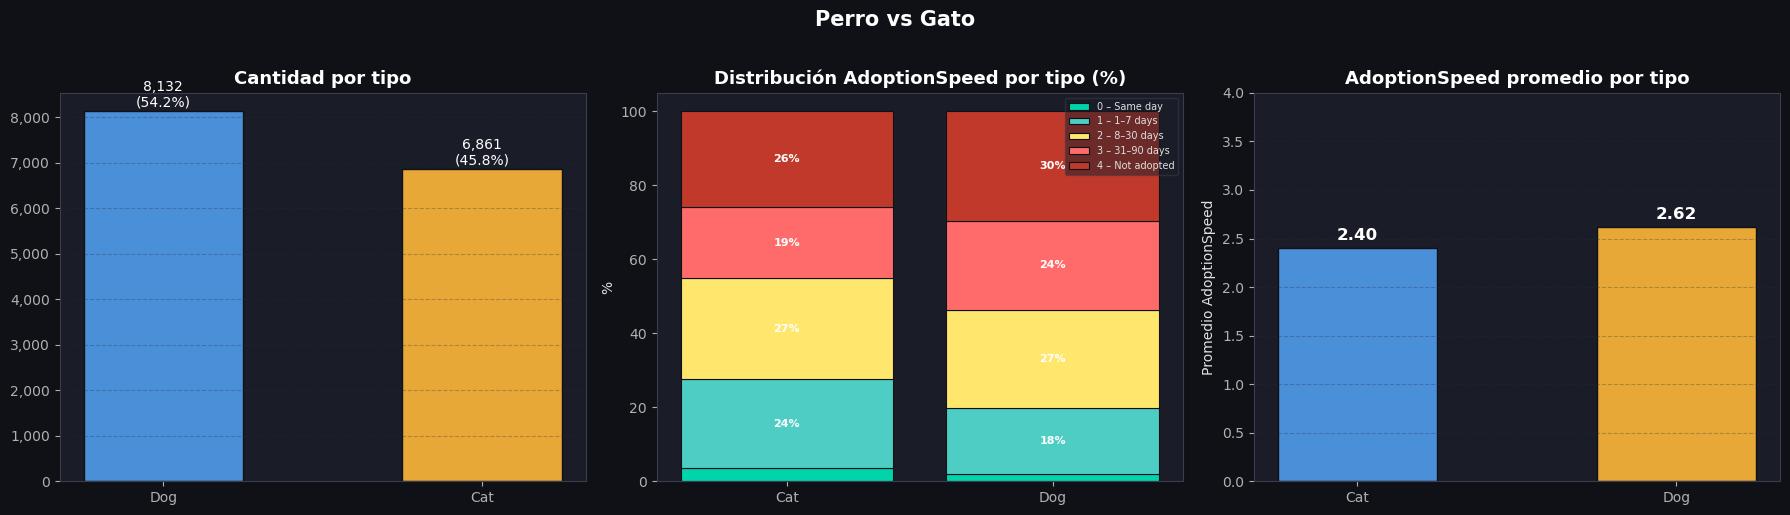

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
fig.suptitle('Perro vs Gato', fontsize=15, fontweight='bold', color='white', y=1.02)

# Overall count
type_counts = train['TypeName'].value_counts()
ax = axes[0]
bars = ax.bar(type_counts.index, type_counts.values,
              color=PALETTE_TYPE, edgecolor='#0f1117', width=0.5)
ax.set_title('Cantidad por tipo')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(train)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, color='white')

# AdoptionSpeed by type
ax = axes[1]
speed_type = train.groupby(['TypeName', 'AdoptionSpeed']).size().unstack(fill_value=0)
speed_type_pct = speed_type.div(speed_type.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(speed_type_pct))
for i, col in enumerate(speed_type_pct.columns):
    vals = speed_type_pct[col].values
    bars2 = ax.bar(speed_type_pct.index, vals, bottom=bottom,
                   label=SPEED_MAP[col], color=PALETTE_SPEED[i],
                   edgecolor='#0f1117', linewidth=0.8)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals
ax.set_title('Distribución AdoptionSpeed por tipo (%)')
ax.set_ylabel('%')
ax.set_facecolor('#1a1d27')
ax.legend(loc='upper right', fontsize=7, framealpha=0.5)

# Median adoption speed by type
ax = axes[2]
means = train.groupby('TypeName')['AdoptionSpeed'].mean()
bars3 = ax.bar(means.index, means.values, color=PALETTE_TYPE,
               edgecolor='#0f1117', width=0.5)
ax.set_title('AdoptionSpeed promedio por tipo')
ax.set_ylabel('Promedio AdoptionSpeed')
ax.set_ylim(0, 4)
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor('#1a1d27')
plt.tight_layout()
plt.show()

## 6. Distribución de edad

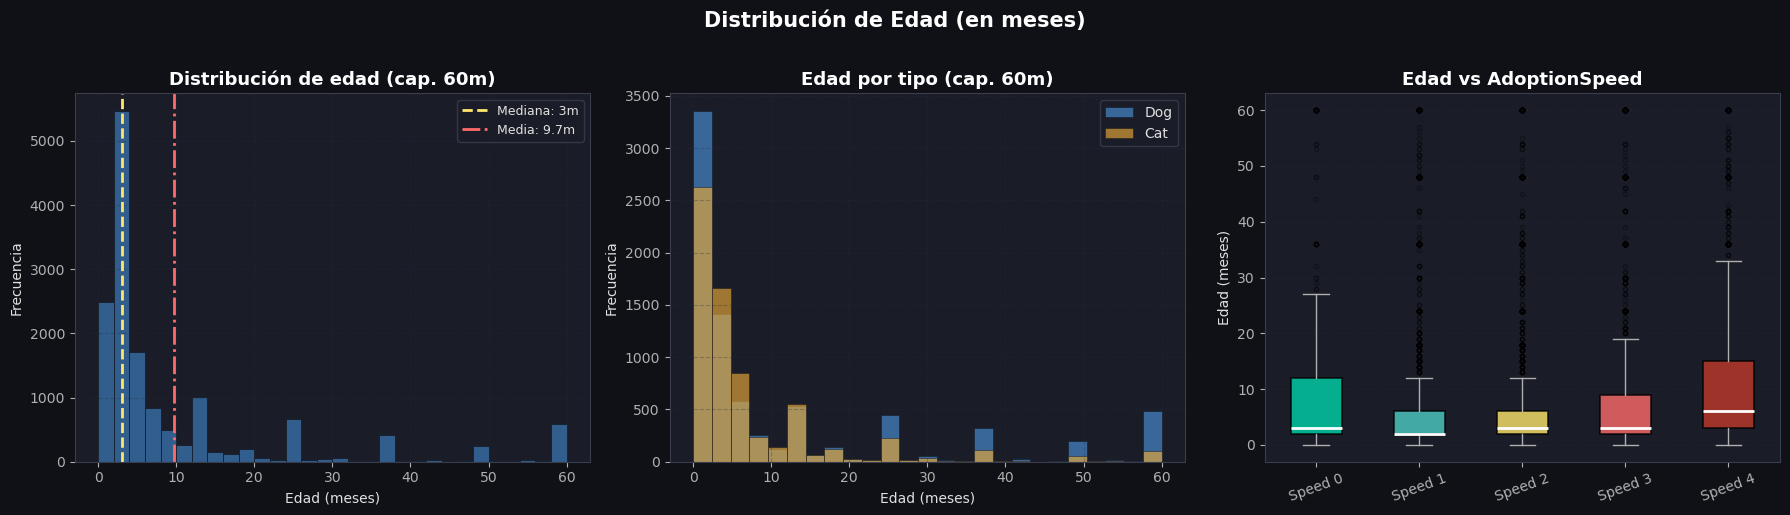

Estadísticas de edad:
count    14993.0
mean        10.5
std         18.2
min          0.0
25%          2.0
50%          3.0
75%         12.0
max        255.0
Name: Age, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
fig.suptitle('Distribución de Edad (en meses)', fontsize=15,
             fontweight='bold', color='white', y=1.02)

# Overall distribution (capped at 60 months = 5 years)
age_cap = train['Age'].clip(upper=60)
ax = axes[0]
ax.hist(age_cap, bins=30, color=PALETTE_MAIN[3], edgecolor='#0f1117',
        linewidth=0.5, alpha=0.85)
ax.axvline(age_cap.median(), color='#ffe66d', lw=2, ls='--',
           label=f'Mediana: {age_cap.median():.0f}m')
ax.axvline(age_cap.mean(), color='#ff6b6b', lw=2, ls='-.',
           label=f'Media: {age_cap.mean():.1f}m')
ax.set_title('Distribución de edad (cap. 60m)')
ax.set_xlabel('Edad (meses)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

# By type
ax = axes[1]
for tname, color in zip(['Dog', 'Cat'], PALETTE_TYPE):
    subset = train[train['TypeName'] == tname]['Age'].clip(upper=60)
    ax.hist(subset, bins=25, alpha=0.65, label=tname,
            color=color, edgecolor='#0f1117', linewidth=0.5)
ax.set_title('Edad por tipo (cap. 60m)')
ax.set_xlabel('Edad (meses)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

# Boxplot age vs AdoptionSpeed
ax = axes[2]
data_by_speed = [train[train['AdoptionSpeed'] == s]['Age'].clip(upper=60).values
                 for s in sorted(train['AdoptionSpeed'].unique())]
bp = ax.boxplot(data_by_speed, patch_artist=True,
                boxprops={'linewidth': 1.2},
                medianprops={'color': 'white', 'linewidth': 2},
                whiskerprops={'color': '#b0b0b0'},
                capprops={'color': '#b0b0b0'},
                flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Edad vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)], rotation=20)
ax.set_ylabel('Edad (meses)')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Estadísticas de edad:')
print(train['Age'].describe().round(1))

## 7. Géneros, tamaño y pelaje

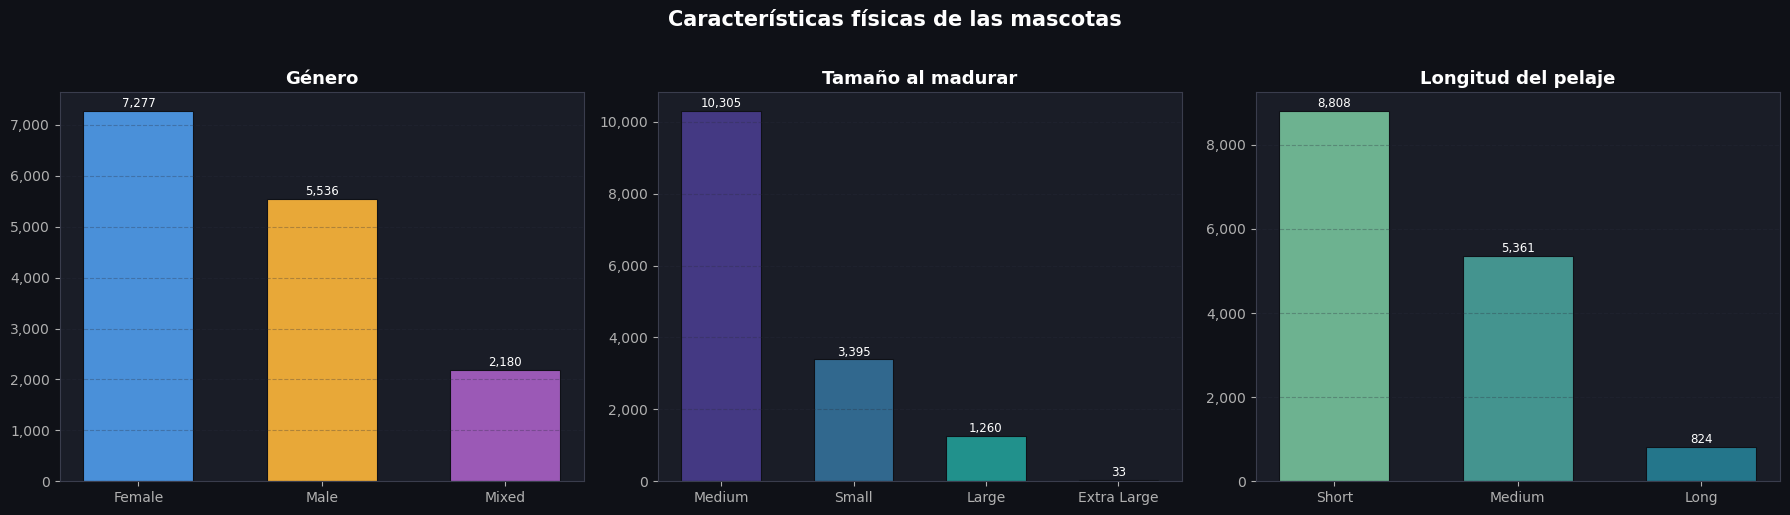

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
fig.suptitle('Características físicas de las mascotas', fontsize=15,
             fontweight='bold', color='white', y=1.02)

def plot_cat_bar(ax, col, title, palette=None):
    counts = train[col].value_counts()
    if palette is None:
        palette = sns.color_palette('mako', len(counts))
    bars = ax.bar(counts.index, counts.values,
                  color=palette[:len(counts)], edgecolor='#0f1117',
                  linewidth=0.8, width=0.6)
    ax.set_title(title)
    ax.set_facecolor('#1a1d27')
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', va='bottom', fontsize=8.5, color='white')

plot_cat_bar(axes[0], 'GenderName',  'Género',
             ['#4A90D9', '#E8A838', '#9B59B6'])
plot_cat_bar(axes[1], 'SizeName',    'Tamaño al madurar',
             sns.color_palette('viridis', 5))
plot_cat_bar(axes[2], 'FurName',     'Longitud del pelaje',
             sns.color_palette('crest', 4))

plt.tight_layout()
plt.show()

## 8. Salud: vacunación, desparasitación, esterilización

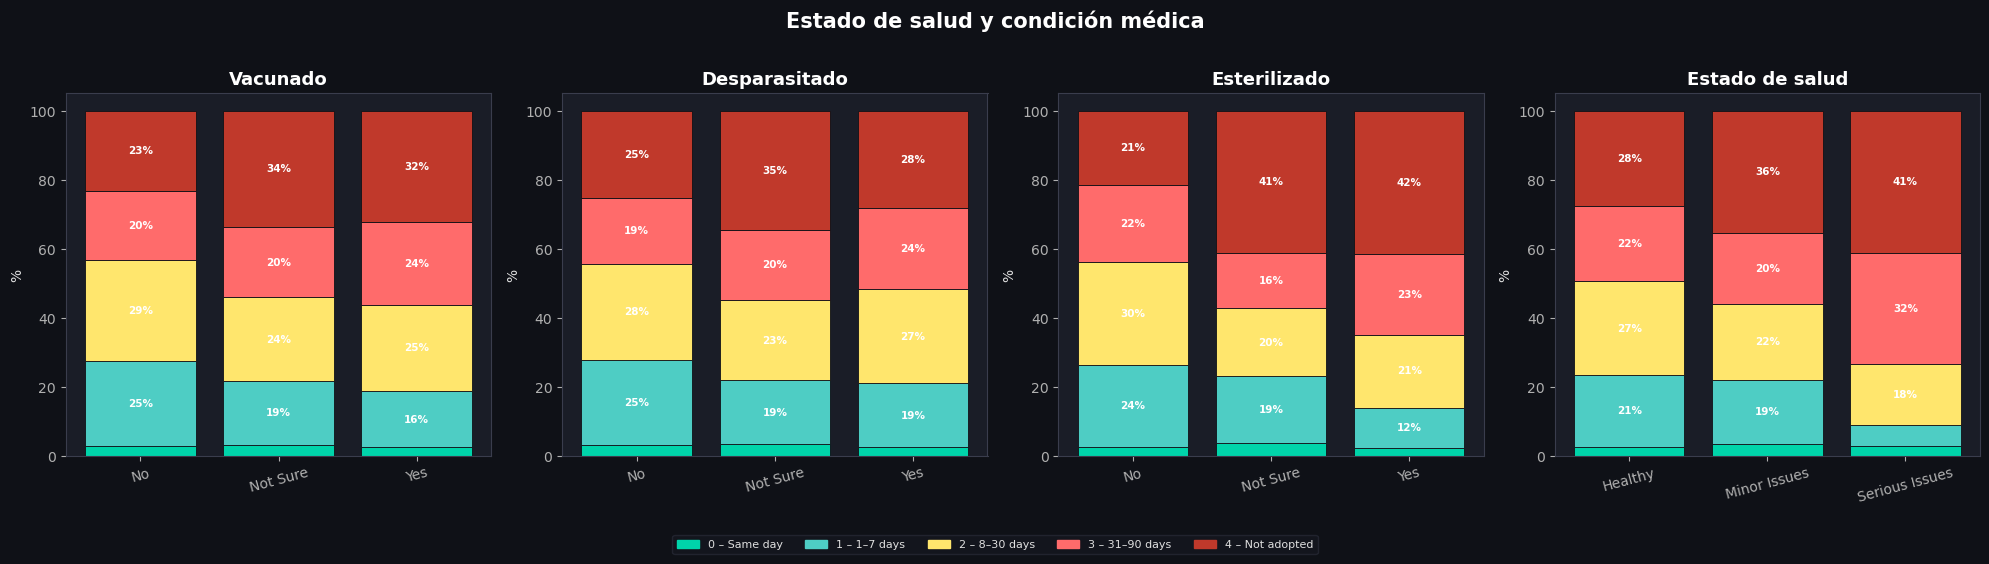

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor='#0f1117')
fig.suptitle('Estado de salud y condición médica', fontsize=15,
             fontweight='bold', color='white', y=1.02)

HEALTH_PALETTE = ['#00d4aa', '#ff6b6b', '#ffe66d']

def stacked_speed(ax, col, title):
    ct = train.groupby([col, 'AdoptionSpeed']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(ct_pct))
    for i, speed_val in enumerate(ct_pct.columns):
        vals = ct_pct[speed_val].values
        ax.bar(ct_pct.index, vals, bottom=bottom,
               label=f'S{speed_val}', color=PALETTE_SPEED[i],
               edgecolor='#0f1117', linewidth=0.6)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 8:
                ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')
        bottom += vals
    ax.set_title(title)
    ax.set_ylabel('%')
    ax.set_facecolor('#1a1d27')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, 105)

stacked_speed(axes[0], 'VaccinatedName', 'Vacunado')
stacked_speed(axes[1], 'DewormedName',   'Desparasitado')
stacked_speed(axes[2], 'SterilizedName', 'Esterilizado')
stacked_speed(axes[3], 'HealthName',     'Estado de salud')

handles = [mpatches.Patch(color=PALETTE_SPEED[i], label=SPEED_MAP[i]) for i in range(5)]
fig.legend(handles=handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.08), fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.show()

## 9. Colores primarios

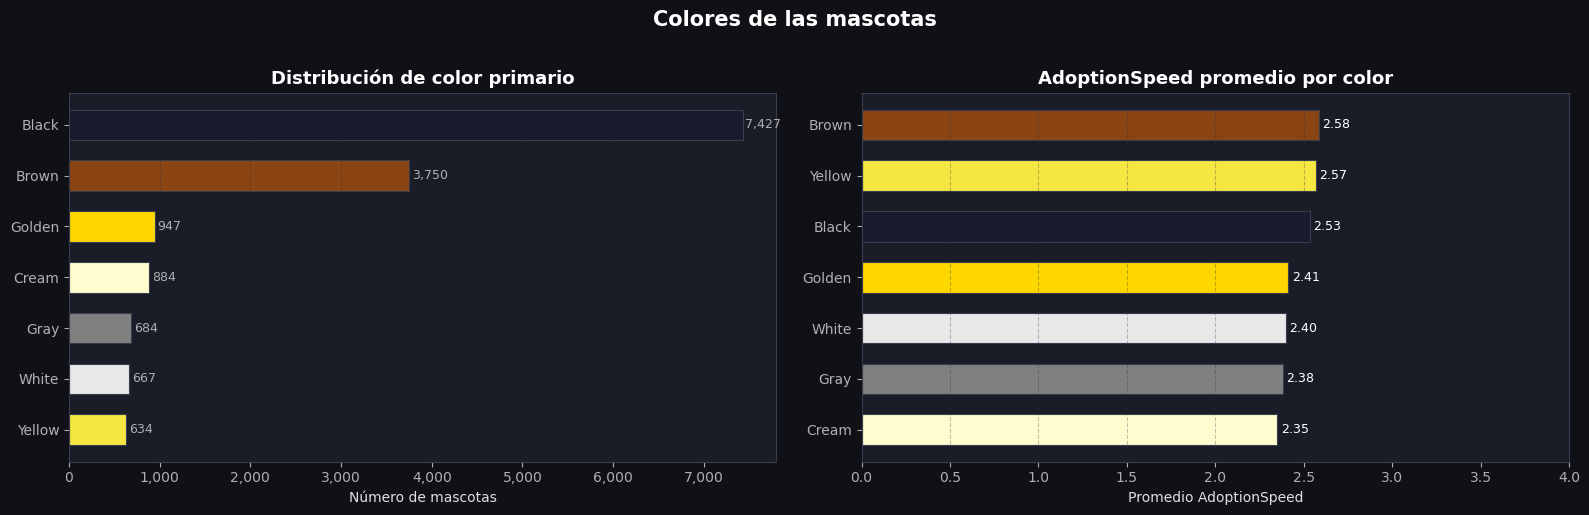

In [10]:
COLOR_HEX = {
    'Black':  '#1a1a2e',
    'Brown':  '#8B4513',
    'Golden': '#FFD700',
    'Yellow': '#F5E642',
    'Cream':  '#FFFDD0',
    'Gray':   '#808080',
    'White':  '#e8e8e8',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f1117')
fig.suptitle('Colores de las mascotas', fontsize=15,
             fontweight='bold', color='white', y=1.02)

# Color counts
ax = axes[0]
color_counts = train['Color1Name'].value_counts()
bar_colors   = [COLOR_HEX.get(c, '#888888') for c in color_counts.index]
bars = ax.barh(color_counts.index[::-1], color_counts.values[::-1],
               color=bar_colors[::-1], edgecolor='#3a3d4d', linewidth=0.8, height=0.6)
ax.set_title('Distribución de color primario')
ax.set_xlabel('Número de mascotas')
ax.set_facecolor('#1a1d27')
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, color_counts.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#b0b0b0')

# Mean adoption speed by color
ax = axes[1]
speed_by_color = train.groupby('Color1Name')['AdoptionSpeed'].mean().sort_values()
bar_colors2 = [COLOR_HEX.get(c, '#888888') for c in speed_by_color.index]
bars2 = ax.barh(speed_by_color.index, speed_by_color.values,
                color=bar_colors2, edgecolor='#3a3d4d', linewidth=0.8, height=0.6)
ax.set_title('AdoptionSpeed promedio por color')
ax.set_xlabel('Promedio AdoptionSpeed')
ax.set_xlim(0, 4)
ax.set_facecolor('#1a1d27')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, speed_by_color.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()

## 10. Distribución geográfica — Estados de Malaysia

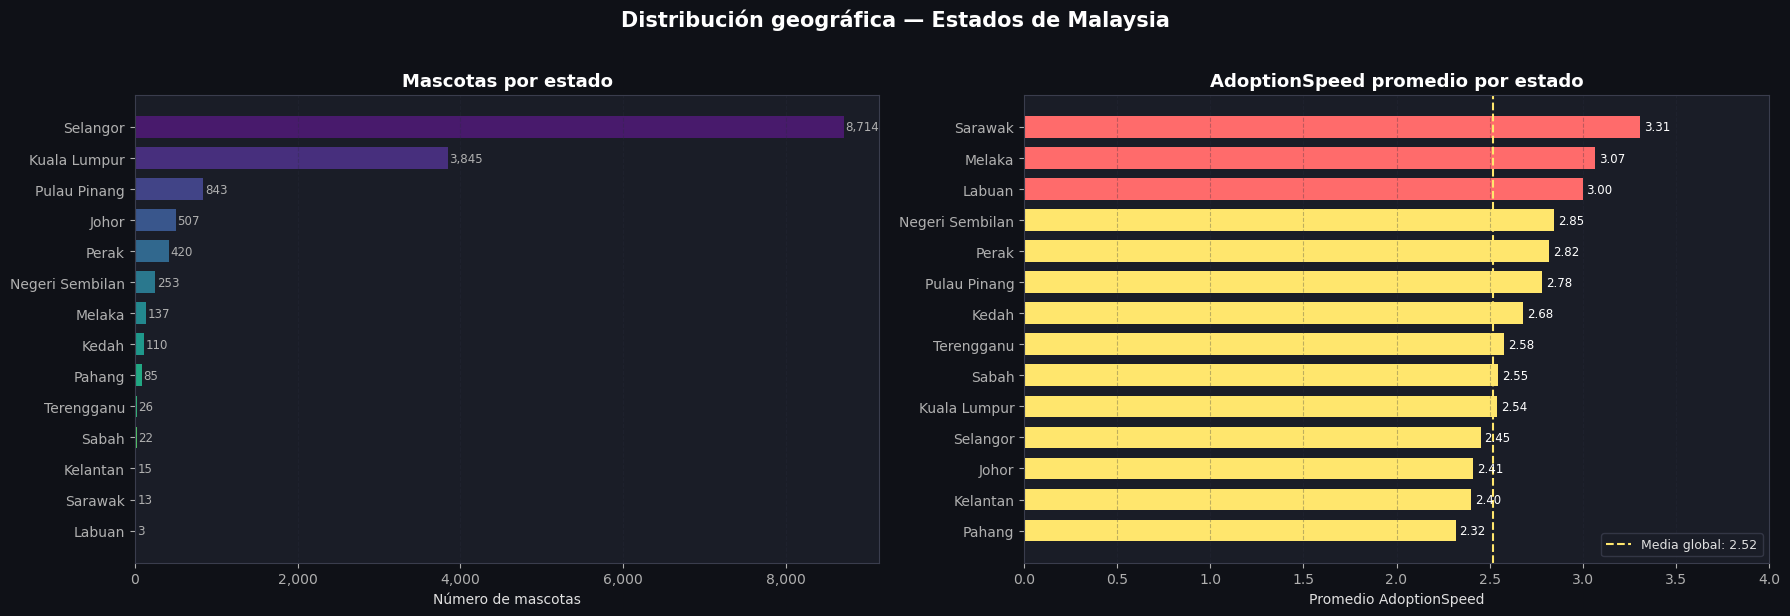

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='#0f1117')
fig.suptitle('Distribución geográfica — Estados de Malaysia', fontsize=15,
             fontweight='bold', color='white', y=1.02)

state_counts = train['StateName'].value_counts()
ax = axes[0]
palette_state = sns.color_palette('viridis', len(state_counts))
bars = ax.barh(state_counts.index[::-1], state_counts.values[::-1],
               color=palette_state[::-1], edgecolor='none', height=0.7)
ax.set_title('Mascotas por estado')
ax.set_xlabel('Número de mascotas')
ax.set_facecolor('#1a1d27')
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, state_counts.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5, color='#b0b0b0')

# Mean AdoptionSpeed by state
ax = axes[1]
speed_state = train.groupby('StateName')['AdoptionSpeed'].mean().sort_values()
colors_speed = [PALETTE_SPEED[min(int(v), 4)] for v in speed_state.values]
bars2 = ax.barh(speed_state.index, speed_state.values,
                color=colors_speed, edgecolor='none', height=0.7)
ax.axvline(train['AdoptionSpeed'].mean(), color='#ffe66d', lw=1.5, ls='--',
           label=f'Media global: {train["AdoptionSpeed"].mean():.2f}')
ax.set_title('AdoptionSpeed promedio por estado')
ax.set_xlabel('Promedio AdoptionSpeed')
ax.set_xlim(0, 4)
ax.set_facecolor('#1a1d27')
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=9)
for bar, val in zip(bars2, speed_state.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8.5, color='white')

plt.tight_layout()
plt.show()

## 11. Tarifa de adopción y cantidad de fotos

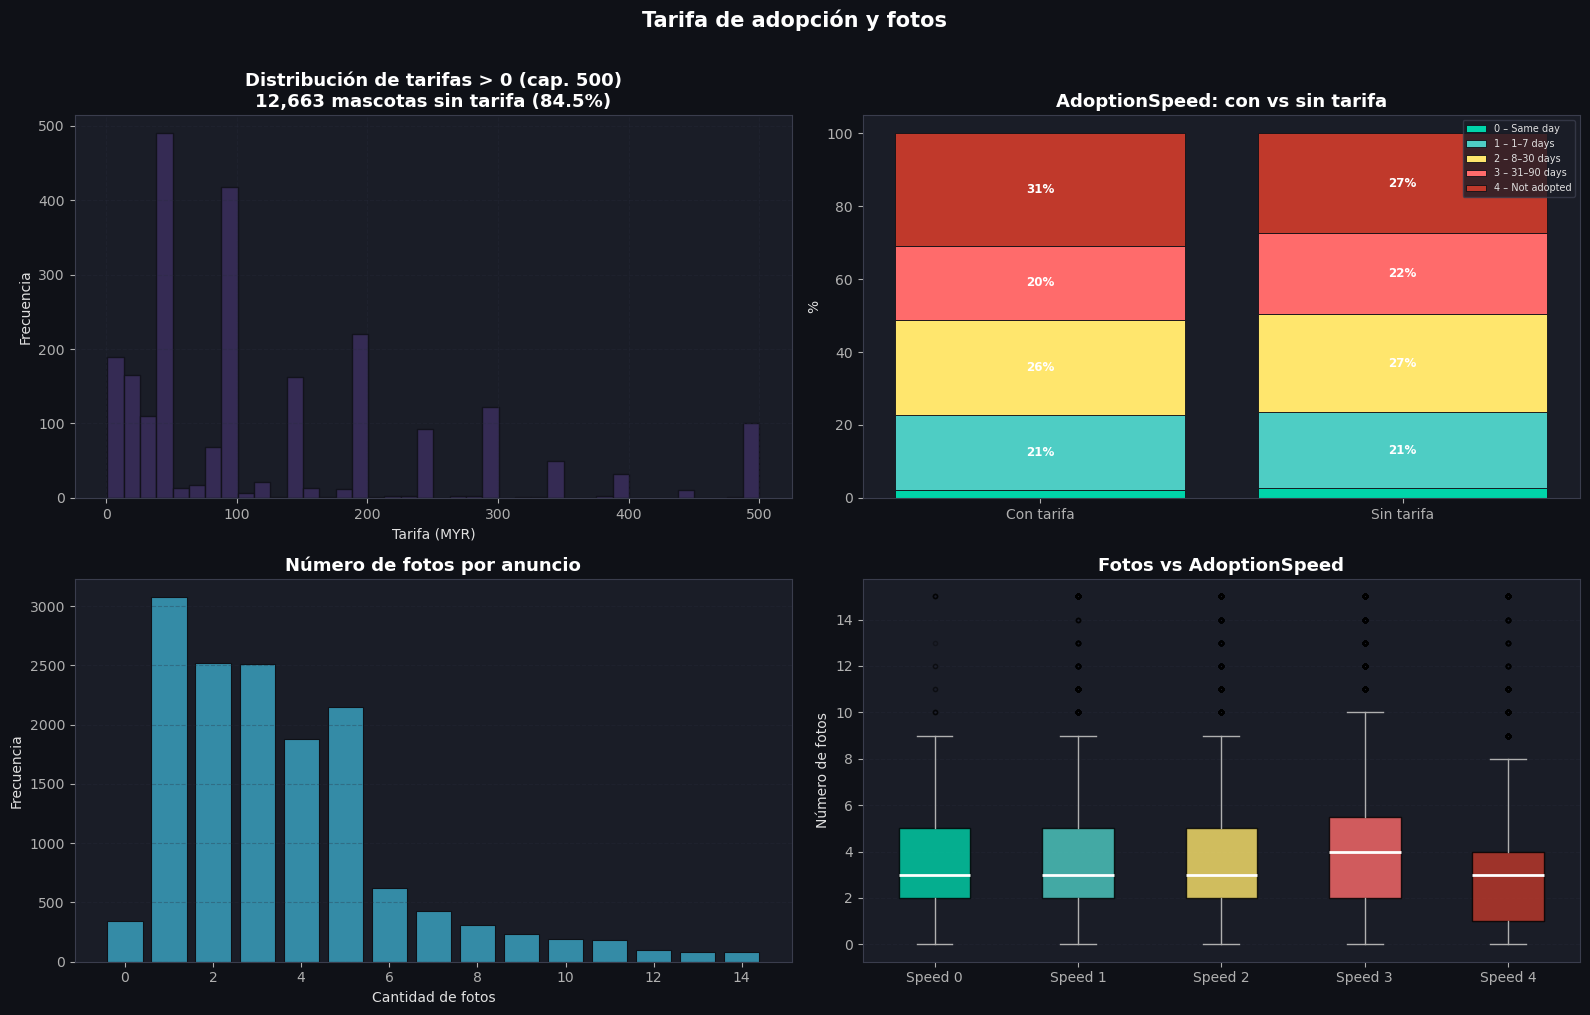

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f1117')
fig.suptitle('Tarifa de adopción y fotos', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# Fee distribution
ax = axes[0, 0]
fee_nonzero = train[train['Fee'] > 0]['Fee'].clip(upper=500)
ax.hist(fee_nonzero, bins=40, color=PALETTE_MAIN[1], edgecolor='#0f1117', alpha=0.85)
ax.set_title(f'Distribución de tarifas > 0 (cap. 500)\n{(train.Fee==0).sum():,} mascotas sin tarifa ({(train.Fee==0).mean()*100:.1f}%)')
ax.set_xlabel('Tarifa (MYR)')
ax.set_ylabel('Frecuencia')
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

# Fee == 0 vs > 0 by adoption speed
ax = axes[0, 1]
train['HasFee'] = train['Fee'].apply(lambda x: 'Con tarifa' if x > 0 else 'Sin tarifa')
ct = train.groupby(['HasFee', 'AdoptionSpeed']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(ct_pct))
for i, sc in enumerate(ct_pct.columns):
    vals = ct_pct[sc].values
    ax.bar(ct_pct.index, vals, bottom=bottom,
           color=PALETTE_SPEED[i], edgecolor='#0f1117', linewidth=0.6,
           label=SPEED_MAP[sc])
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += vals
ax.set_title('AdoptionSpeed: con vs sin tarifa')
ax.set_ylabel('%')
ax.set_facecolor('#1a1d27')
ax.legend(fontsize=7, loc='upper right')

# Photo count distribution
ax = axes[1, 0]
photo_counts = train['PhotoAmt'].fillna(0).value_counts().sort_index().head(15)
ax.bar(photo_counts.index.astype(int), photo_counts.values,
       color=PALETTE_MAIN[4], edgecolor='#0f1117', linewidth=0.8)
ax.set_title('Número de fotos por anuncio')
ax.set_xlabel('Cantidad de fotos')
ax.set_ylabel('Frecuencia')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

# Boxplot photos vs AdoptionSpeed
ax = axes[1, 1]
data_ph = [train[train['AdoptionSpeed'] == s]['PhotoAmt'].fillna(0).clip(upper=15).values
           for s in sorted(train['AdoptionSpeed'].unique())]
bp = ax.boxplot(data_ph, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2},
                whiskerprops={'color': '#b0b0b0'},
                capprops={'color': '#b0b0b0'},
                flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Fotos vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)])
ax.set_ylabel('Número de fotos')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Razas más populares

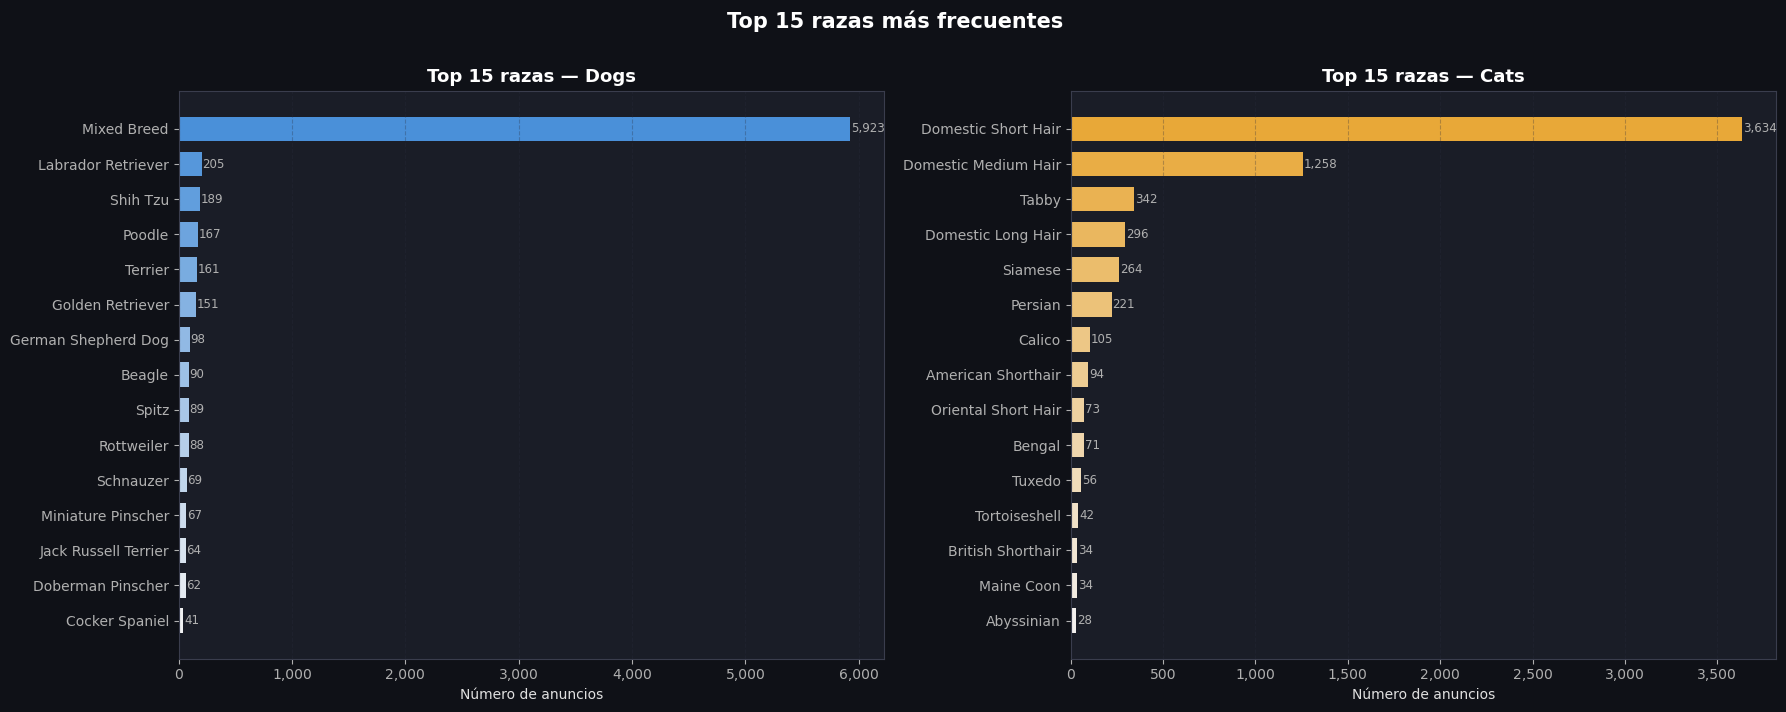

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0f1117')
fig.suptitle('Top 15 razas más frecuentes', fontsize=15,
             fontweight='bold', color='white', y=1.01)

for ax, pet_type, color in zip(axes, ['Dog', 'Cat'], PALETTE_TYPE):
    subset = train[train['TypeName'] == pet_type]
    top_breeds = subset['Breed1Name'].value_counts().head(15)
    palette = sns.light_palette(color, n_colors=len(top_breeds), reverse=True)
    bars = ax.barh(top_breeds.index[::-1], top_breeds.values[::-1],
                   color=palette[::-1], edgecolor='none', height=0.7)
    ax.set_title(f'Top 15 razas — {pet_type}s')
    ax.set_xlabel('Número de anuncios')
    ax.set_facecolor('#1a1d27')
    ax.grid(axis='x', alpha=0.3)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for bar, val in zip(bars, top_breeds.values[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8.5, color='#b0b0b0')

plt.tight_layout()
plt.show()

## 13. Análisis de sentimientos de las descripciones

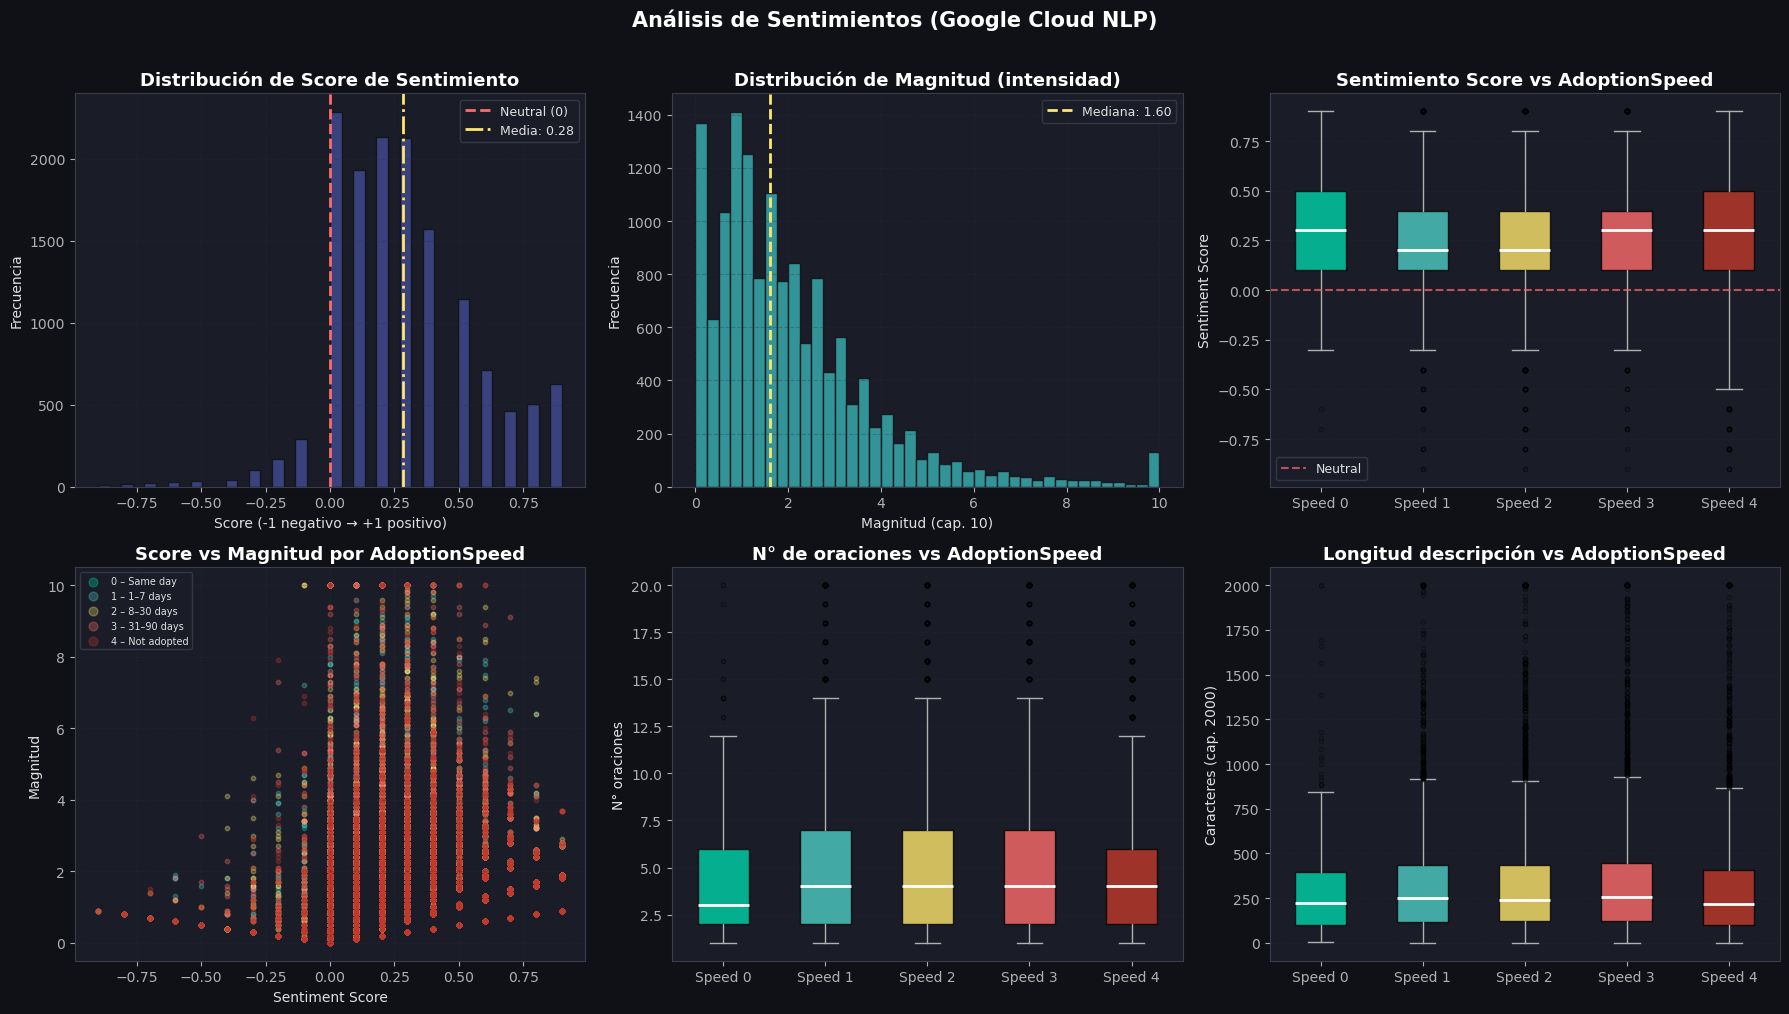

Estadísticas de sentimiento:
       sent_score   sent_mag  n_sentences
count   14204.000  14204.000    14204.000
mean        0.281      2.095        5.035
std         0.278      1.984        4.649
min        -0.900      0.000        1.000
25%         0.100      0.800        2.000
50%         0.300      1.600        4.000
75%         0.400      2.800        6.000
max         0.900     32.000       84.000


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#0f1117')
fig.suptitle('Análisis de Sentimientos (Google Cloud NLP)', fontsize=15,
             fontweight='bold', color='white', y=1.01)

sent_df = train.dropna(subset=['sent_score', 'sent_mag'])

# Score distribution
ax = axes[0, 0]
ax.hist(sent_df['sent_score'], bins=40, color=PALETTE_MAIN[2],
        edgecolor='#0f1117', alpha=0.85)
ax.axvline(0, color='#ff6b6b', lw=2, ls='--', label='Neutral (0)')
ax.axvline(sent_df['sent_score'].mean(), color='#ffe66d', lw=2, ls='-.',
           label=f'Media: {sent_df["sent_score"].mean():.2f}')
ax.set_title('Distribución de Score de Sentimiento')
ax.set_xlabel('Score (-1 negativo → +1 positivo)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

# Magnitude distribution
ax = axes[0, 1]
ax.hist(sent_df['sent_mag'].clip(upper=10), bins=40, color=PALETTE_MAIN[5],
        edgecolor='#0f1117', alpha=0.85)
ax.axvline(sent_df['sent_mag'].median(), color='#ffe66d', lw=2, ls='--',
           label=f'Mediana: {sent_df["sent_mag"].median():.2f}')
ax.set_title('Distribución de Magnitud (intensidad)')
ax.set_xlabel('Magnitud (cap. 10)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

# Score vs AdoptionSpeed boxplot
ax = axes[0, 2]
data_sent = [sent_df[sent_df['AdoptionSpeed'] == s]['sent_score'].values
             for s in sorted(sent_df['AdoptionSpeed'].unique())]
bp = ax.boxplot(data_sent, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2},
                whiskerprops={'color': '#b0b0b0'},
                capprops={'color': '#b0b0b0'},
                flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.axhline(0, color='#ff6b6b', lw=1.5, ls='--', alpha=0.7, label='Neutral')
ax.set_title('Sentimiento Score vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)])
ax.set_ylabel('Sentiment Score')
ax.legend(fontsize=9)
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

# Score vs Magnitude scatter colored by speed
ax = axes[1, 0]
for speed_val, color in zip(range(5), PALETTE_SPEED):
    sub = sent_df[sent_df['AdoptionSpeed'] == speed_val]
    ax.scatter(sub['sent_score'], sub['sent_mag'].clip(upper=10),
               c=color, alpha=0.3, s=10, label=SPEED_MAP[speed_val])
ax.set_title('Score vs Magnitud por AdoptionSpeed')
ax.set_xlabel('Sentiment Score')
ax.set_ylabel('Magnitud')
ax.legend(fontsize=7, markerscale=2)
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

# Número de oraciones
ax = axes[1, 1]
data_sent2 = [sent_df[sent_df['AdoptionSpeed'] == s]['n_sentences'].clip(upper=20).values
              for s in sorted(sent_df['AdoptionSpeed'].unique())]
bp2 = ax.boxplot(data_sent2, patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2},
                 whiskerprops={'color': '#b0b0b0'},
                 capprops={'color': '#b0b0b0'},
                 flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp2['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_title('N° de oraciones vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)])
ax.set_ylabel('N° oraciones')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

# Longitud descripción vs AdoptionSpeed
ax = axes[1, 2]
data_desc = [train[train['AdoptionSpeed'] == s]['DescLen'].clip(upper=2000).values
             for s in sorted(train['AdoptionSpeed'].unique())]
bp3 = ax.boxplot(data_desc, patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2},
                 whiskerprops={'color': '#b0b0b0'},
                 capprops={'color': '#b0b0b0'},
                 flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp3['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_title('Longitud descripción vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)])
ax.set_ylabel('Caracteres (cap. 2000)')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Estadísticas de sentimiento:')
print(sent_df[['sent_score', 'sent_mag', 'n_sentences']].describe().round(3))

## 14. Anotaciones de imágenes — Google Cloud Vision API

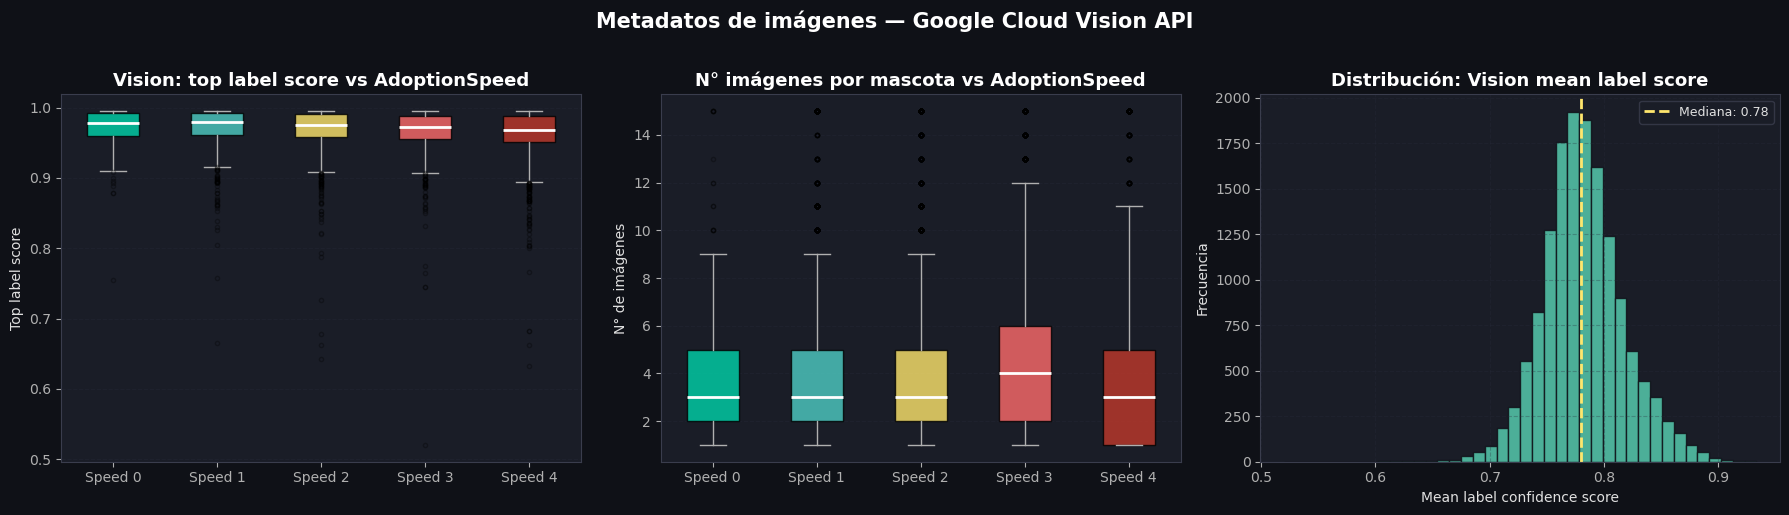

In [15]:
meta_df = train.dropna(subset=['vision_top_score', 'vision_mean_score'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
fig.suptitle('Metadatos de imágenes — Google Cloud Vision API', fontsize=15,
             fontweight='bold', color='white', y=1.02)

# Vision top score by adoption speed
ax = axes[0]
data_vis = [meta_df[meta_df['AdoptionSpeed'] == s]['vision_top_score'].values
            for s in sorted(meta_df['AdoptionSpeed'].unique())]
bp = ax.boxplot(data_vis, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2},
                whiskerprops={'color': '#b0b0b0'},
                capprops={'color': '#b0b0b0'},
                flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_title('Vision: top label score vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)])
ax.set_ylabel('Top label score')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

# Number of images vs adoption speed
ax = axes[1]
data_nim = [meta_df[meta_df['AdoptionSpeed'] == s]['n_images'].clip(upper=15).values
            for s in sorted(meta_df['AdoptionSpeed'].unique())]
bp2 = ax.boxplot(data_nim, patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2},
                 whiskerprops={'color': '#b0b0b0'},
                 capprops={'color': '#b0b0b0'},
                 flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp2['boxes'], PALETTE_SPEED):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_title('N° imágenes por mascota vs AdoptionSpeed')
ax.set_xticklabels([f'Speed {i}' for i in range(5)])
ax.set_ylabel('N° de imágenes')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

# Vision mean score distribution
ax = axes[2]
ax.hist(meta_df['vision_mean_score'], bins=40, color=PALETTE_MAIN[6],
        edgecolor='#0f1117', alpha=0.85)
ax.axvline(meta_df['vision_mean_score'].median(), color='#ffe66d', lw=2, ls='--',
           label=f'Mediana: {meta_df["vision_mean_score"].median():.2f}')
ax.set_title('Distribución: Vision mean label score')
ax.set_xlabel('Mean label confidence score')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.set_facecolor('#1a1d27')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Cantidad de mascotas por anuncio y presencia de nombre

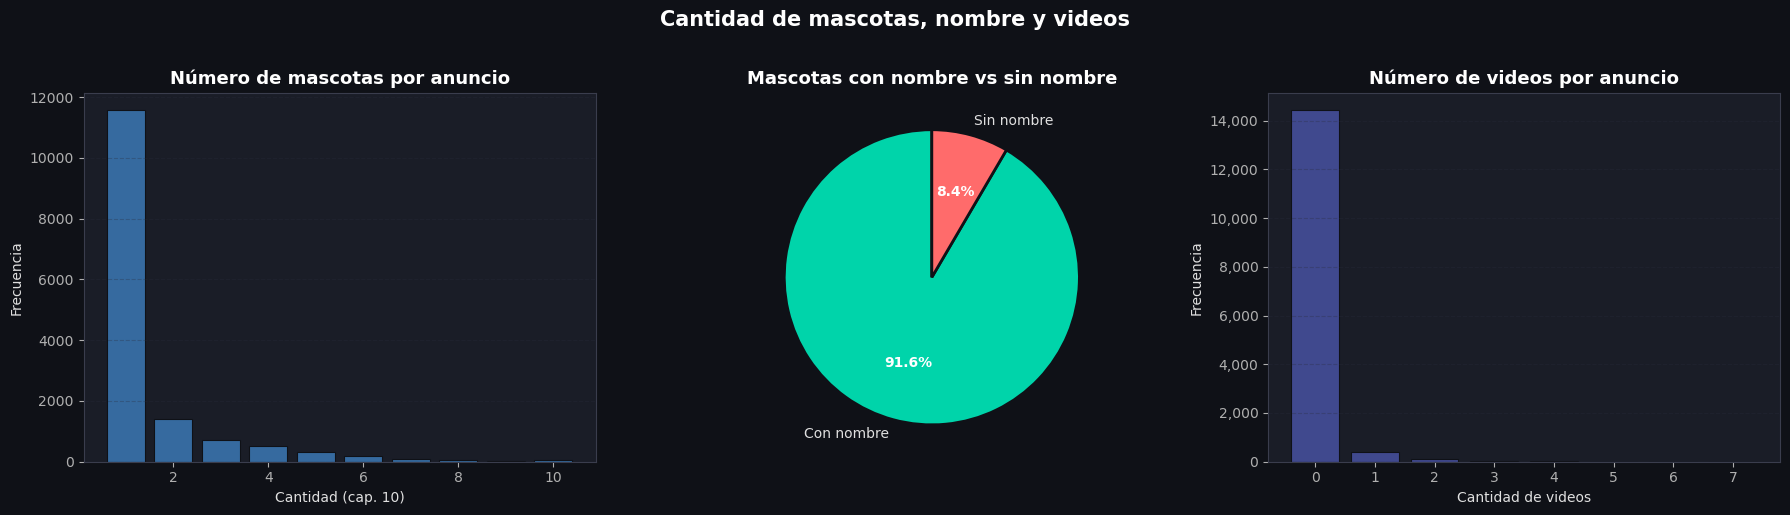

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
fig.suptitle('Cantidad de mascotas, nombre y videos', fontsize=15,
             fontweight='bold', color='white', y=1.02)

# Quantity distribution
ax = axes[0]
qty = train['Quantity'].clip(upper=10).value_counts().sort_index()
ax.bar(qty.index, qty.values, color=PALETTE_MAIN[3],
       edgecolor='#0f1117', linewidth=0.8)
ax.set_title('Número de mascotas por anuncio')
ax.set_xlabel('Cantidad (cap. 10)')
ax.set_ylabel('Frecuencia')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)

# Has name
ax = axes[1]
name_counts = train['HasName'].value_counts()
colors_name = ['#00d4aa', '#ff6b6b']
labels_name = ['Con nombre', 'Sin nombre']
wedges, texts, auts = ax.pie(
    name_counts.values, labels=labels_name,
    colors=colors_name, autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
for t in texts:  t.set_color('#e0e0e0')
for at in auts:  at.set_color('white'); at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title('Mascotas con nombre vs sin nombre')
ax.set_facecolor('#1a1d27')

# VideoAmt distribution
ax = axes[2]
video = train['VideoAmt'].value_counts().sort_index().head(8)
ax.bar(video.index, video.values, color=PALETTE_MAIN[2],
       edgecolor='#0f1117', linewidth=0.8)
ax.set_title('Número de videos por anuncio')
ax.set_xlabel('Cantidad de videos')
ax.set_ylabel('Frecuencia')
ax.set_facecolor('#1a1d27')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 16. Mapa de correlaciones

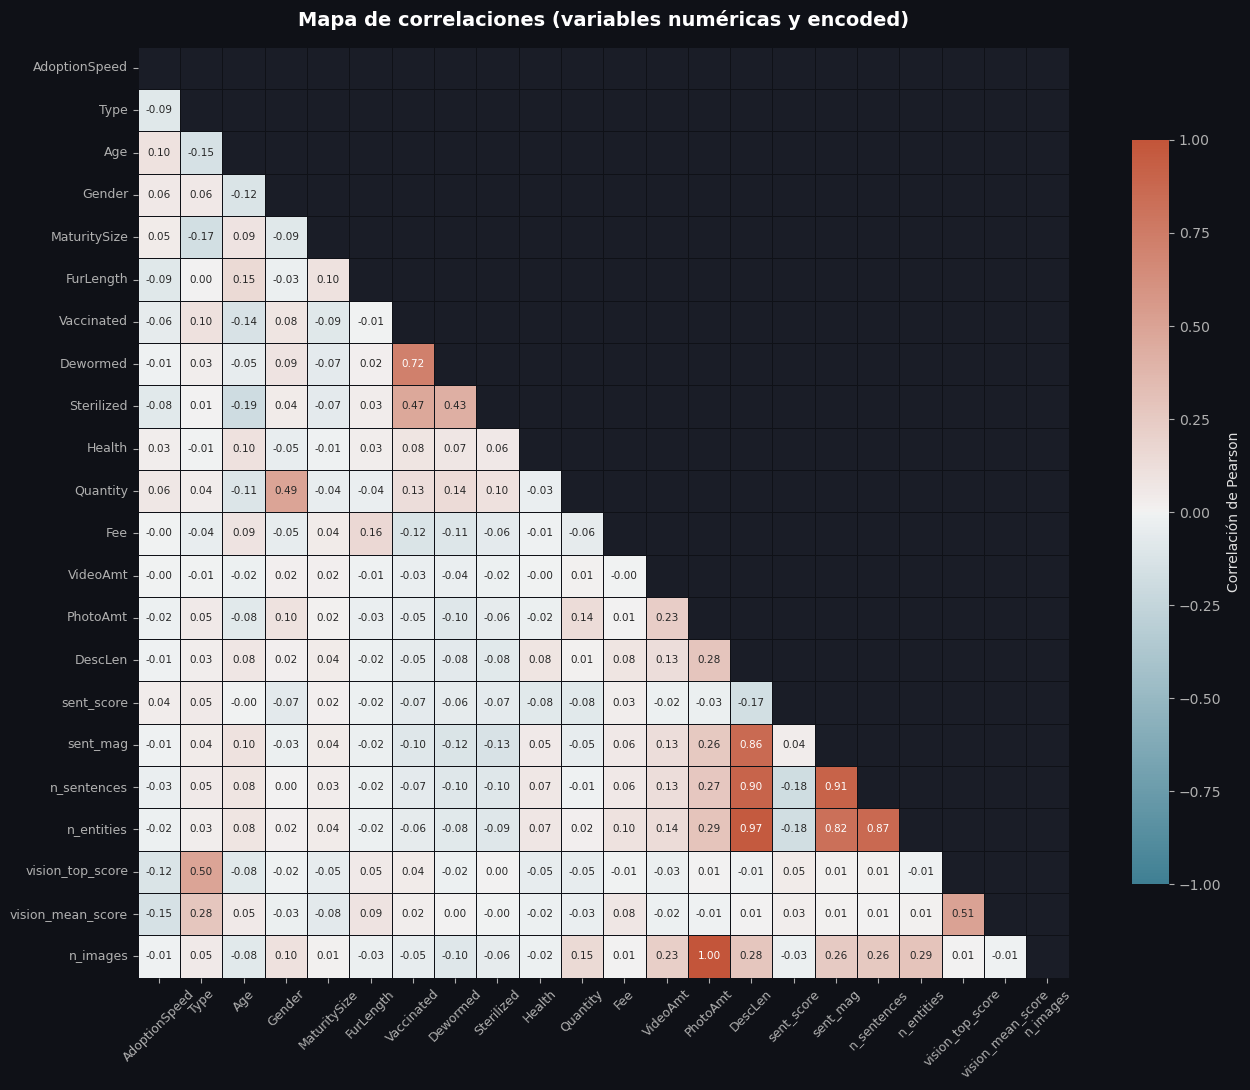


Top correlaciones con AdoptionSpeed (|r|):
  -0.146  vision_mean_score
  -0.121  vision_top_score
  +0.101  Age
  -0.091  FurLength
  -0.091  Type
  -0.083  Sterilized
  +0.063  Quantity
  -0.059  Vaccinated
  +0.058  Gender
  +0.046  MaturitySize


In [17]:
num_cols = [
    'AdoptionSpeed', 'Type', 'Age', 'Gender', 'MaturitySize', 'FurLength',
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity',
    'Fee', 'VideoAmt', 'PhotoAmt', 'DescLen',
    'sent_score', 'sent_mag', 'n_sentences', 'n_entities',
    'vision_top_score', 'vision_mean_score', 'n_images',
]
num_cols = [c for c in num_cols if c in train.columns]

corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11), facecolor='#0f1117')
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    linewidths=0.5, linecolor='#0f1117',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
)
ax.set_title('Mapa de correlaciones (variables numéricas y encoded)', fontsize=14,
             fontweight='bold', color='white', pad=15)
ax.set_facecolor('#1a1d27')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['AdoptionSpeed'].drop('AdoptionSpeed').abs().sort_values(ascending=False)
print('\nTop correlaciones con AdoptionSpeed (|r|):')
for feat, val in target_corr.head(10).items():
    sign = '+' if corr.loc[feat, 'AdoptionSpeed'] > 0 else '-'
    print(f'  {sign}{val:.3f}  {feat}')

## 17. Dashboard resumen — KPIs clave

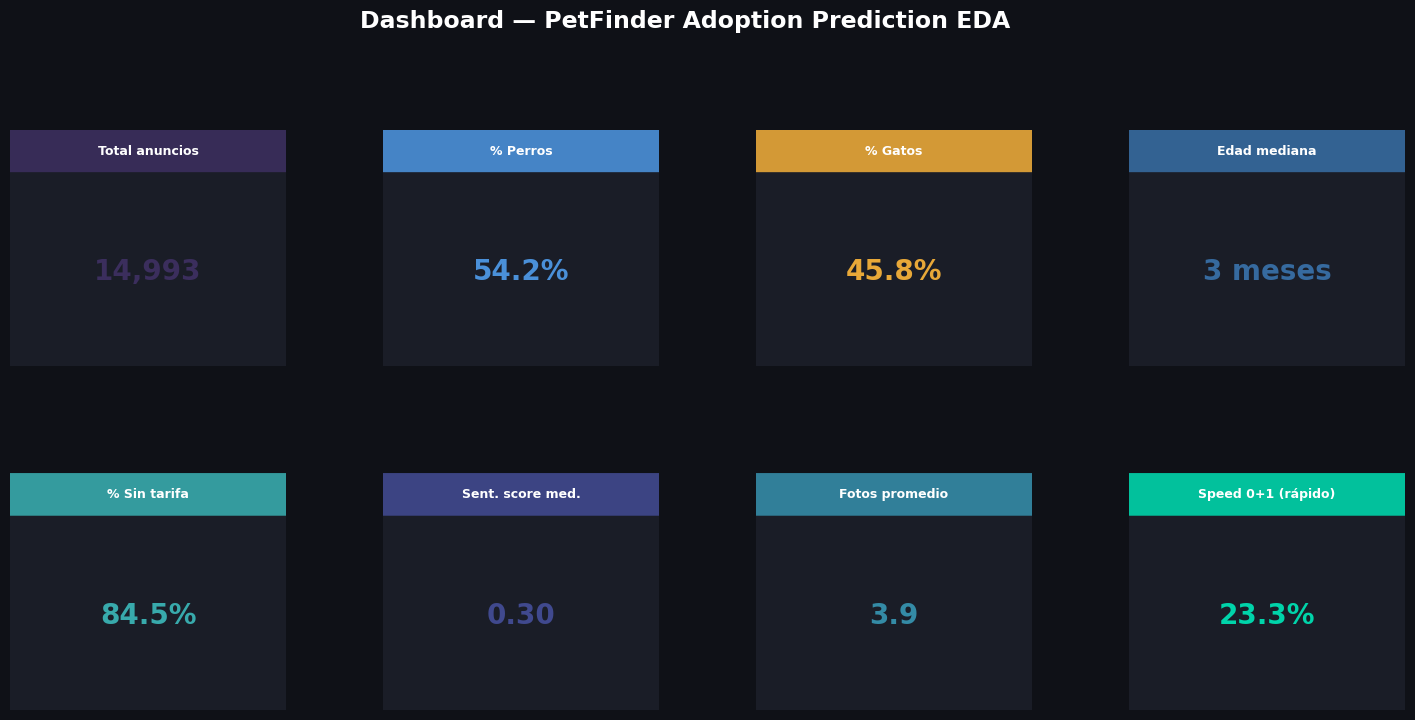


RESUMEN EJECUTIVO DEL DATASET
  Registros entrenamiento : 14,993
  Registros test          : 3,972
  Columnas originales     : 24 (23 features + 1 target)
  Perros / Gatos          : 8,132 / 6,861
  Edad media (meses)      : 10.5 ± 18.2
  % sin tarifa            : 84.5%
  % con sentimiento       : 94.7%
  % con imágenes           : 97.7%
  Sent. score promedio    : 0.28 (mayoritariamente positivo)
  Fotos promedio          : 3.9

  Distribución AdoptionSpeed:
    Speed 0 (0 – Same day): 410 (2.7%) ████
    Speed 1 (1 – 1–7 days): 3,090 (20.6%) ██████████████████████████████
    Speed 2 (2 – 8–30 days): 4,037 (26.9%) ████████████████████████████████████████
    Speed 3 (3 – 31–90 days): 3,259 (21.7%) ████████████████████████████████
    Speed 4 (4 – Not adopted): 4,197 (28.0%) █████████████████████████████████████████


In [18]:
fig = plt.figure(figsize=(18, 12), facecolor='#0f1117')
gs  = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Dashboard — PetFinder Adoption Prediction EDA', fontsize=17,
             fontweight='bold', color='white', y=0.98)

# ── KPI cards ──────────────────────────────────────────────────────────
kpis = [
    ('Total anuncios',   f'{len(train):,}',                  PALETTE_MAIN[1]),
    ('% Perros',         f'{(train.Type==1).mean()*100:.1f}%', PALETTE_TYPE[0]),
    ('% Gatos',          f'{(train.Type==2).mean()*100:.1f}%', PALETTE_TYPE[1]),
    ('Edad mediana',     f'{int(train.Age.median())} meses',  PALETTE_MAIN[3]),
    ('% Sin tarifa',     f'{(train.Fee==0).mean()*100:.1f}%', PALETTE_MAIN[5]),
    ('Sent. score med.', f'{train.sent_score.median():.2f}',  PALETTE_MAIN[2]),
    ('Fotos promedio',   f'{train.PhotoAmt.mean():.1f}',      PALETTE_MAIN[4]),
    ('Speed 0+1 (rápido)',f'{(train.AdoptionSpeed.isin([0,1])).mean()*100:.1f}%', '#00d4aa'),
]

for idx, (label, value, color) in enumerate(kpis):
    row, col = divmod(idx, 4)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor('#1a1d27')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    # Colored top bar
    ax.add_patch(FancyBboxPatch((0, 0), 1, 1,
                                boxstyle='round,pad=0.05',
                                facecolor='#1a1d27',
                                edgecolor=color, linewidth=2))
    ax.add_patch(FancyBboxPatch((0, 0.82), 1, 0.18,
                                boxstyle='round,pad=0',
                                facecolor=color, alpha=0.9,
                                edgecolor='none'))
    ax.text(0.5, 0.91, label, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    ax.text(0.5, 0.40, value, ha='center', va='center',
            fontsize=20, color=color, fontweight='bold')

plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print('\n' + '='*60)
print('RESUMEN EJECUTIVO DEL DATASET')
print('='*60)
print(f'  Registros entrenamiento : {len(train):,}')
print(f'  Registros test          : {len(test):,}')
print(f'  Columnas originales     : 24 (23 features + 1 target)')
print(f'  Perros / Gatos          : {(train.Type==1).sum():,} / {(train.Type==2).sum():,}')
print(f'  Edad media (meses)      : {train.Age.mean():.1f} ± {train.Age.std():.1f}')
print(f'  % sin tarifa            : {(train.Fee==0).mean()*100:.1f}%')
print(f'  % con sentimiento       : {train.sent_score.notna().mean()*100:.1f}%')
print(f'  % con imágenes           : {train.vision_top_score.notna().mean()*100:.1f}%')
print(f'  Sent. score promedio    : {train.sent_score.mean():.2f} (mayoritariamente positivo)')
print(f'  Fotos promedio          : {train.PhotoAmt.mean():.1f}')
print()
print('  Distribución AdoptionSpeed:')
for s, row in train['AdoptionSpeed'].value_counts().sort_index().items():
    bar = '█' * int(row / 100)
    print(f'    Speed {s} ({SPEED_MAP[s][:20]}): {row:,} ({row/len(train)*100:.1f}%) {bar}')
print('='*60)